##  01 Data Exploration

**Goal:** Understand and anlyze the Flickr30k dataset  
  
**Sections**
1. Setup & loading
2. Dataset statistics
3. Image analysis
4. Data quality checks

In [1]:
# import libraries 
import sys
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

# pytorch frameworks 
import torch
from torchvision import transforms
from transformers import DistilBertTokenizer
from pathlib import Path

d:\Projects\CLIP-Style-MultiModal-Retrieval-System\.env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#  add the project root to the Python path
#import project modules from anywhere inside the project without errors.
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [3]:
# Import our centralized paths
from src.utils.paths import (
    FLICKR30K_IMAGES_DIR,
    CAPTIONS_FILE,
    SPLITS_DIR,
    ensure_base_dirs
)

In [4]:
#  Ensure all necessary directories exist 
ensure_base_dirs()

In [6]:
# Configure plotting
#Setting up how plots (graphs) will look
sns.set_theme(style = "whitegrid" , )
plt.rcParams["figure.figsize"] = (10,6)
print(f"Images Directory: {FLICKR30K_IMAGES_DIR}")
print(f"Captions File: {CAPTIONS_FILE}")
print(f"Images directory exists: {FLICKR30K_IMAGES_DIR.exists()}")

Images Directory: D:\Projects\CLIP-Style-MultiModal-Retrieval-System\data\raw\flickr30k_images
Captions File: D:\Projects\CLIP-Style-MultiModal-Retrieval-System\data\raw\captions.txt
Images directory exists: True


### Section 1: Load and Validate Raw Data
First, we load the captions using our centralized `CAPTIONS_FILE` path and ensure the standard Flickr30k format (1 image to 5 captions) is intact.

In [5]:
# load the dataset 
df = pd.read_csv(CAPTIONS_FILE , sep= ",")

df.head(10)



,image_name,comment_number,comment
0,1000092795.jpg,0,Two young guys with shaggy hair look at their ...
1,1000092795.jpg,1,Two young White males are outside near many b...
2,1000092795.jpg,2,Two men in green shirts are standing in a yard .
3,1000092795.jpg,3,A man in a blue shirt standing in a garden .
4,1000092795.jpg,4,Two friends enjoy time spent together .
5,10002456.jpg,0,Several men in hard hats are operating a giant...
6,10002456.jpg,1,Workers look down from up above on a piece of ...
7,10002456.jpg,2,Two men working on a machine wearing hard hats .
8,10002456.jpg,3,Four men on top of a tall structure .
9,10002456.jpg,4,Three men on a large rig .


In [6]:
# clean columns  spaces 
df.columns = [col.strip() for col in df.columns ] 



In [7]:
print(df.columns)

Index(['image_name', 'comment_number', 'comment'], dtype='str')


In [8]:
# Ensure correct data types and clean text
df['comment'] = df['comment'].astype(str).str.strip()

print(f"Total rows (captions): {len(df)}")
print(f"Unique images: {df['image_name'].nunique()}")

Total rows (captions): 158915
Unique images: 31783


In [9]:
# Count how many captions exist for each unique image
counts = df.groupby('image_name').size()
counts 

image_name
1000092795.jpg    5
10002456.jpg      5
1000268201.jpg    5
1000344755.jpg    5
1000366164.jpg    5
                 ..
997338199.jpg     5
997722733.jpg     5
997876722.jpg     5
99804383.jpg      5
998845445.jpg     5
Length: 31783, dtype: int64

In [10]:
perfect_count = (counts == 5).sum()
missing_count = (counts < 5).sum()
duplicate_count = (counts > 5).sum()



In [11]:
if missing_count > 0 or duplicate_count > 0:
    print("dataset isn't clean ")
else:
    print("\nDataset is perfectly clean. No action needed.")


Dataset is perfectly clean. No action needed.


In [12]:
a = 158915/31783
a

5.0

In [13]:
# finding any empty or nan cell 
df.isnull().sum()

image_name        0
comment_number    0
comment           0
dtype: int64

In [14]:
# finding duplicate values 
duplicate = df.duplicated().sum()
print(duplicate)


0


### 2. Image analysis 

In [17]:
# first  plot a image for trial
img = df["image_name"].drop_duplicates().sample(1, random_state=42).iloc[0]

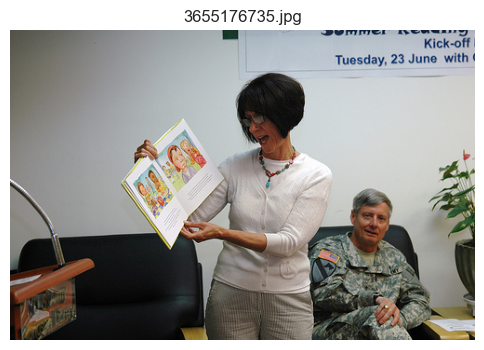

In [18]:
img_path = FLICKR30K_IMAGES_DIR / img
image = Image.open(img_path).convert("RGB")
plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title(img)
plt.axis("off")
plt.show()

In [19]:
img2 = df['image_name'].drop_duplicates().sample(4 , random_state=42)

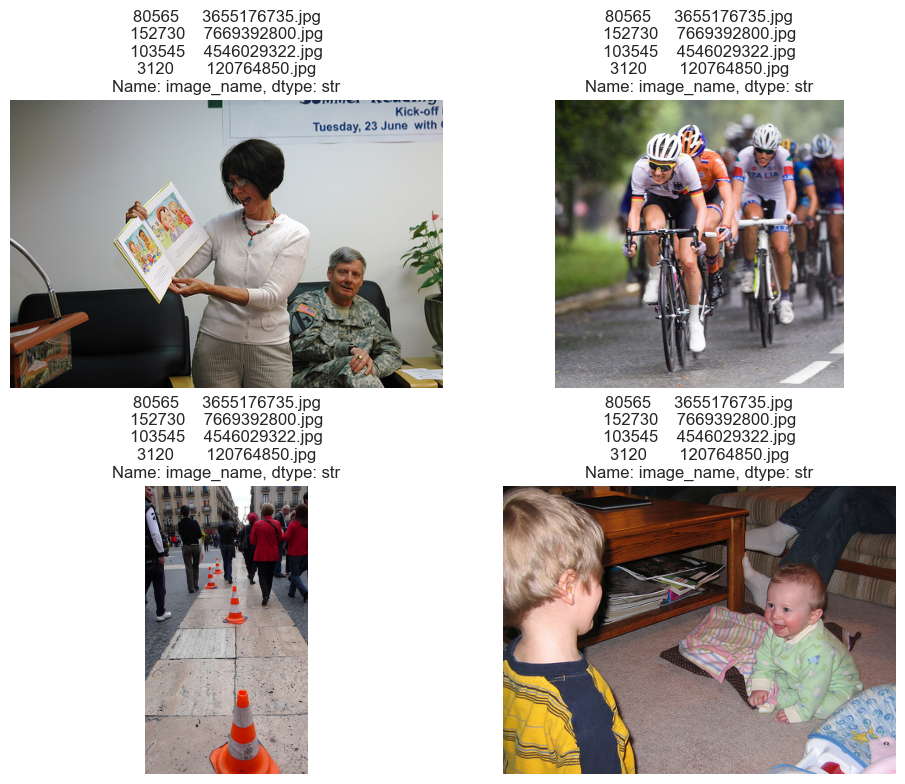

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, img_name in zip(axes, img2):
    img_path = FLICKR30K_IMAGES_DIR / img_name
    image = Image.open(img_path).convert("RGB")

    ax.imshow(image)
    ax.set_title(img2)
    ax.axis("off")

# Step 5: adjust spacing and show
plt.tight_layout()
plt.show()

In [ ]:
# now we open all images and find there dimensions and convert them into df 
results = []

for img_name in df["image_name"].drop_duplicates():
    img_path = FLICKR30K_IMAGES_DIR / img_name
    
    try:
        image = Image.open(img_path)
        
        width, height = image.size   # (W, H)
        aspect_ratio = width / height
        
        results.append({
            "image_name": img_name,
            "width": width,
            "height": height,
            "aspect_ratio": aspect_ratio
        })
        
    except Exception as e:
        print(f"Error with {img_name}: {e}")

# Convert to DataFrame
meta_df = pd.DataFrame(results)

In [ ]:
meta_df.head()

,image_name,width,height,aspect_ratio
0,1000092795.jpg,333,500,0.666000
1,10002456.jpg,500,374,1.336898
2,1000268201.jpg,375,500,0.750000
3,1000344755.jpg,500,333,1.501502
4,1000366164.jpg,500,375,1.333333


In [ ]:
meta_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31783 entries, 0 to 31782
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   image_name    31783 non-null  str    
 1   width         31783 non-null  int64  
 2   height        31783 non-null  int64  
 3   aspect_ratio  31783 non-null  float64
dtypes: float64(1), int64(2), str(1)
memory usage: 993.3 KB


In [ ]:
meta_df.describe()

,width,height,aspect_ratio
count,31783.000000,31783.000000,31783.000000
mean,459.607148,395.131485,1.228410
std,67.482044,74.361142,0.354524
min,164.000000,112.000000,0.328000
25%,395.000000,333.000000,0.796000
50%,500.000000,375.000000,1.333333
75%,500.000000,500.000000,1.501502
max,500.000000,500.000000,4.464286


In [ ]:
meta_df.shape

(31783, 4)

In [ ]:
size_counts = meta_df[["width", "height"]].value_counts().reset_index(name="count")

In [ ]:
size_counts = size_counts.sort_values(by="count", ascending=False)

In [ ]:
size_counts.head(5)

,width,height,count
0,500,333,6421
1,500,375,6247
2,333,500,2570
3,375,500,2311
4,500,334,1415


In [ ]:
size_counts.size

2250

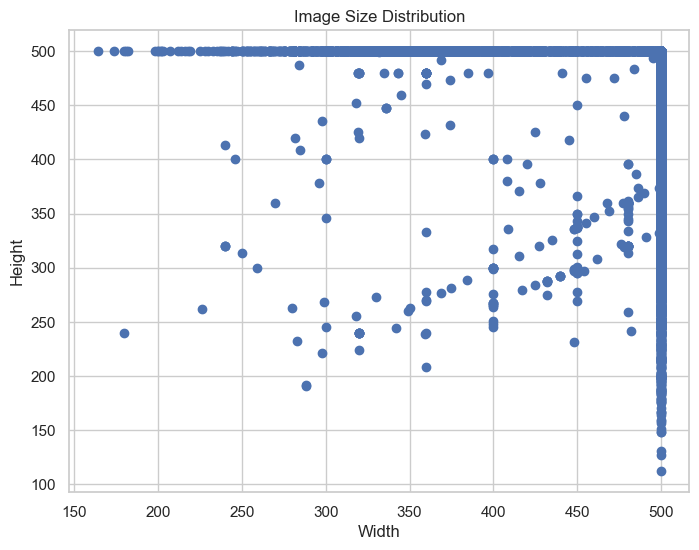

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(meta_df["width"], meta_df["height"])

plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Size Distribution")

plt.show()

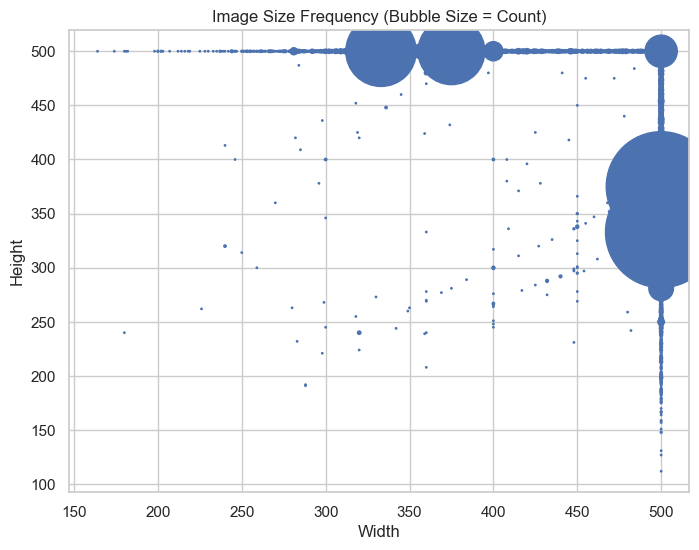

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    size_counts["width"],
    size_counts["height"],
    s=size_counts["count"]  # bubble size = count
)

plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Size Frequency (Bubble Size = Count)")

plt.show()

#####  The "500px Cap" Quirk
* **Observation:** The absolute maximum width and height in the entire dataset is exactly 500 pixels. 
* **Insight:** Flickr30k is not raw camera data; it was pre-processed by its creators so that the longest edge never exceeds 500px. The median image is a standard landscape (`500x333` or `500x375`).

#### 1.2 The Color Channel Check (Tensor Shape Audit)
Pre-trained Vision Encoders (ResNet, ViT) require an exact tensor depth of `3` (Red, Green, Blue). If any image in the dataset is Grayscale (Mode `L`, depth 1) or transparent (Mode `RGBA`, depth 4), it will crash the matrix multiplication in the first convolutional layer. 

We will read the raw headers of all images to tally their modes before deciding on our preprocessing rules.

In [16]:
from collections import Counter

image_modes = Counter()
corrupted_images = []

# We check ALL unique images in our currently active dataframe
all_images = df['image_name'].unique()

for img_name in tqdm(all_images, desc="Checking Color Channels"):
    img_path = FLICKR30K_IMAGES_DIR / img_name
    try:
        # STEP 1: The Raw Read. 
        with Image.open(img_path) as img:
            
            # STEP 2: The Tally
            image_modes[img.mode] += 1
            
    except Exception as e:
        corrupted_images.append((img_name, str(e)))

# STEP 3: The Proportional Decision
print( "Channel Tally Results")
total_checked = sum(image_modes.values())

for mode, count in image_modes.most_common():
    percentage = (count / total_checked) * 100
    print(f"Mode '{mode}': {count:5} images ({percentage:.4f}%)")

print(f"\nTotal Corrupted/Unreadable Images found here: {len(corrupted_images)}")

# Programmatic Conclusion
rgb_count = image_modes.get('RGB', 0)
non_rgb_count = total_checked - rgb_count

print("\n--- Engineering Action Required ---")
if non_rgb_count > 0:
    print(f"WARNING: Found {non_rgb_count} non-RGB images.")
    print("ACTION: You MUST explicitly apply `.convert('RGB')` to every image inside your `src/data/dataset.py` __getitem__ method to prevent Tensor shape crashes during training.")
else:
    print("Dataset is 100% RGB.")
    print("ACTION: Safest practice is still to include `.convert('RGB')` in your dataset class as defensive programming against future data updates.")

Checking Color Channels: 100%|Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†| 31783/31783 [10:19<00:00, 51.29it/s]

Channel Tally Results
Mode 'RGB': 31783 images (100.0000%)

Total Corrupted/Unreadable Images found here: 0

--- Engineering Action Required ---
Dataset is 100% RGB.
ACTION: Safest practice is still to include `.convert('RGB')` in your dataset class as defensive programming against future data updates.


### Section 3: Text Deep-Dive Profiling
This section adds four advanced text audits:
1. Token & Compute Profiling
2. Lexical & Semantic Topology
3. Multi-Caption Dynamics (1 image : 5 captions)
4. Dataset Pathology & Noise Auditing
        


In [15]:
# Section 3 setup (text-only analysis frame)
from collections import Counter
from itertools import combinations
import re
import math

In [16]:
TEXT_COL = 'comment'
IMAGE_COL = 'image_name'

text_df = df[[IMAGE_COL, TEXT_COL]].copy()
text_df[TEXT_COL] = text_df[TEXT_COL].astype(str).str.strip()
text_df = text_df[text_df[TEXT_COL].str.len() > 0].reset_index(drop=True)

In [17]:
# Lower + whitespace normalization (keeps original text intact)
text_df['comment_norm'] = (
    text_df[TEXT_COL]
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# Lightweight tokenization for lexical analysis (not WordPiece)
text_df['tokens'] = text_df['comment_norm'].str.findall(r"[a-z0-9]+(?:'[a-z0-9]+)?")

print(f"Text rows available: {len(text_df):,}")
print(f"Unique images represented: {text_df[IMAGE_COL].nunique():,}")

Text rows available: 158,915
Unique images represented: 31,783


In [18]:
# DistilBERT tokenizer for true compute/OOV profiling
try:
    tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
    print('Tokenizer loaded: distilbert-base-uncased')
except Exception as e:
    tokenizer = None
    print('Tokenizer load failed. Install/check transformers model cache and rerun this section.')
    print('Error:', e)
        


d:\Projects\CLIP-Style-MultiModal-Retrieval-System\.env\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\mahlawat\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Tokenizer loaded: distilbert-base-uncased


#### 3.1 Token & Compute Profiling
- Sub-word sequence distribution after WordPiece tokenization
- OOV / `[UNK]` profiling and unknown raw-word frequency
        


WordPiece length profiling: 100%|Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†| 158915/158915 [00:33<00:00, 4741.35it/s]


WordPiece sequence length stats
- Mean   : 15.79
- Median : 15.00
- P95    : 26.00
- P99    : 34.00
- Max    : 83


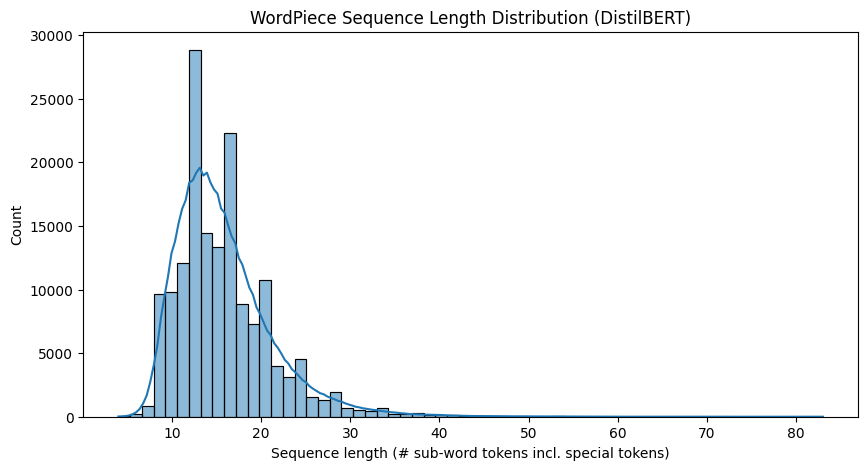

UNK token rate profiling: 100%|Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†| 156/156 [00:06<00:00, 24.40it/s]


Sub-word OOV ([UNK]) rate: 0.000000% (0/2,192,214)


Unknown raw-word scan: 100%|Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†| 18297/18297 [00:01<00:00, 10625.30it/s]

Unique raw words that trigger [UNK]: 0


,count
tokens,


In [19]:
if tokenizer is None:
    print('Skip this cell: tokenizer not available.')
else:
    # ---- A) Sub-word sequence distribution (true compute footprint)
    wp_seq_lens = []
    for txt in tqdm(text_df[TEXT_COL], desc='WordPiece length profiling'):
        ids = tokenizer.encode(txt, add_special_tokens=True, truncation=False)
        wp_seq_lens.append(len(ids))

    text_df['wp_seq_len'] = wp_seq_lens

    p50, p95, p99 = np.percentile(text_df['wp_seq_len'], [50, 95, 99])
    print('WordPiece sequence length stats')
    print(f"- Mean   : {text_df['wp_seq_len'].mean():.2f}")
    print(f"- Median : {p50:.2f}")
    print(f"- P95    : {p95:.2f}")
    print(f"- P99    : {p99:.2f}")
    print(f"- Max    : {text_df['wp_seq_len'].max()}")

    plt.figure(figsize=(10, 5))
    sns.histplot(text_df['wp_seq_len'], bins=60, kde=True)
    plt.title('WordPiece Sequence Length Distribution (DistilBERT)')
    plt.xlabel('Sequence length (# sub-word tokens incl. special tokens)')
    plt.ylabel('Count')
    plt.show()

    # ---- B) Vocabulary coverage / OOV rate at sub-word level
    unk_id = tokenizer.unk_token_id
    total_subwords = 0
    total_unk = 0
    batch_size = 1024

    for i in tqdm(range(0, len(text_df), batch_size), desc='UNK token rate profiling'):
        batch_text = text_df[TEXT_COL].iloc[i:i+batch_size].tolist()
        enc = tokenizer(batch_text, add_special_tokens=False, truncation=False)
        for ids in enc['input_ids']:
            total_subwords += len(ids)
            total_unk += sum(1 for t in ids if t == unk_id)

    oov_rate = (total_unk / total_subwords) if total_subwords else 0.0
    print(f"Sub-word OOV ([UNK]) rate: {oov_rate:.6%} ({total_unk:,}/{total_subwords:,})")

    # ---- C) Most frequent raw words that map to [UNK] (domain-gap probe)
    raw_words = text_df['tokens'].explode().dropna()
    unique_words = raw_words.unique().tolist()

    unknown_word_set = set()
    for w in tqdm(unique_words, desc='Unknown raw-word scan'):
        ids = tokenizer.encode(w, add_special_tokens=False)
        if unk_id in ids:
            unknown_word_set.add(w)

    unknown_word_counts = (
        raw_words[raw_words.isin(unknown_word_set)]
        .value_counts()
        .head(30)
    )

    print(f"Unique raw words that trigger [UNK]: {len(unknown_word_set):,}")
    display(unknown_word_counts.to_frame('count'))
        


#### 3.2 Lexical & Semantic Topology
- Top noun/verb frequency map (bias audit)
- POS ratio profiling (noun vs verb vs adjective vs preposition)
- Zipf-style rank-frequency visualization
        


In [20]:
import nltk

# Ensure NLTK tagger resources are present
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    try:
        nltk.download('averaged_perceptron_tagger_eng', quiet=True)
    except Exception:
        nltk.download('averaged_perceptron_tagger', quiet=True)

In [21]:
# POS tagging all caption token lists
token_lists = text_df['tokens'].tolist()
all_pos_tags = []
for toks in tqdm(token_lists, desc='POS tagging captions'):
    if toks:
        all_pos_tags.append(nltk.pos_tag(toks))
    else:
        all_pos_tags.append([])

text_df['pos_tags'] = all_pos_tags

noun_counter = Counter()
verb_counter = Counter()
adj_counter = Counter()
prep_counter = Counter()

for sent in text_df['pos_tags']:
    for word, tag in sent:
        if tag.startswith('NN'):
            noun_counter[word] += 1
        elif tag.startswith('VB'):
            verb_counter[word] += 1
        elif tag.startswith('JJ'):
            adj_counter[word] += 1
        elif tag == 'IN':
            prep_counter[word] += 1

noun_total = sum(noun_counter.values())
verb_total = sum(verb_counter.values())
adj_total = sum(adj_counter.values())
prep_total = sum(prep_counter.values())
tracked_total = noun_total + verb_total + adj_total + prep_total

print('POS aggregate counts')
print(f"- Nouns       : {noun_total:,}")
print(f"- Verbs       : {verb_total:,}")
print(f"- Adjectives  : {adj_total:,}")
print(f"- Prepositions: {prep_total:,}")


POS tagging captions: 100%|Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†| 158915/158915 [02:21<00:00, 1120.61it/s]


POS aggregate counts
- Nouns       : 665,876
- Verbs       : 284,907
- Adjectives  : 174,113
- Prepositions: 295,322


In [22]:
if tracked_total > 0:
    print('POS aggregate ratios')
    print(f"- Nouns       : {noun_total/tracked_total:.2%}")
    print(f"- Verbs       : {verb_total/tracked_total:.2%}")
    print(f"- Adjectives  : {adj_total/tracked_total:.2%}")
    print(f"- Prepositions: {prep_total/tracked_total:.2%}")

noun_top100 = pd.DataFrame(noun_counter.most_common(100), columns=['noun', 'count'])
verb_top100 = pd.DataFrame(verb_counter.most_common(100), columns=['verb', 'count'])

if noun_total > 0:
    noun_top100['pct_of_nouns'] = noun_top100['count'] / noun_total
if verb_total > 0:
    verb_top100['pct_of_verbs'] = verb_top100['count'] / verb_total

print('Top 20 nouns')
display(noun_top100.head(20))
print('Top 20 verbs')
display(verb_top100.head(20))

# Bias snapshot for common concepts (example terms requested in prompt)
for focus in ['man', 'dog', 'shirt']:
    freq = noun_counter.get(focus, 0)
    pct = (freq / noun_total) if noun_total else 0
    print(f"Noun bias -> '{focus}': {freq:,} ({pct:.2%} of all noun tokens)")

POS aggregate ratios
- Nouns       : 46.89%
- Verbs       : 20.06%
- Adjectives  : 12.26%
- Prepositions: 20.79%
Top 20 nouns


,noun,count,pct_of_nouns
0,man,42626,0.064015
1,woman,22213,0.033359
2,people,17338,0.026038
3,shirt,14261,0.021417
4,men,9498,0.014264
5,girl,9142,0.013729
6,boy,9062,0.013609
7,dog,9036,0.013570
8,street,7999,0.012013
9,group,7853,0.011793


Top 20 verbs


,verb,count,pct_of_verbs
0,is,41117,0.144317
1,are,20196,0.070886
2,wearing,15403,0.054063
3,sitting,9560,0.033555
4,standing,8551,0.030013
5,playing,7786,0.027328
6,holding,6962,0.024436
7,walking,6943,0.024369
8,looking,5120,0.017971
9,dressed,3453,0.012120


Noun bias -> 'man': 42,626 (6.40% of all noun tokens)
Noun bias -> 'dog': 9,036 (1.36% of all noun tokens)
Noun bias -> 'shirt': 14,261 (2.14% of all noun tokens)


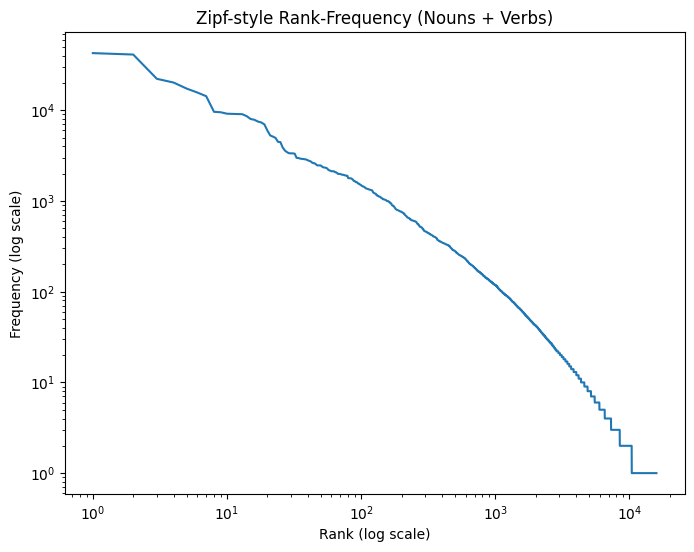

In [23]:
# Zipf-like rank-frequency map over noun+verb lexicon
lex_counter = noun_counter + verb_counter
freqs = sorted(lex_counter.values(), reverse=True)
if freqs:
    ranks = np.arange(1, len(freqs) + 1)
    plt.figure(figsize=(8, 6))
    plt.loglog(ranks, freqs)
    plt.title('Zipf-style Rank-Frequency (Nouns + Verbs)')
    plt.xlabel('Rank (log scale)')
    plt.ylabel('Frequency (log scale)')
    plt.show()


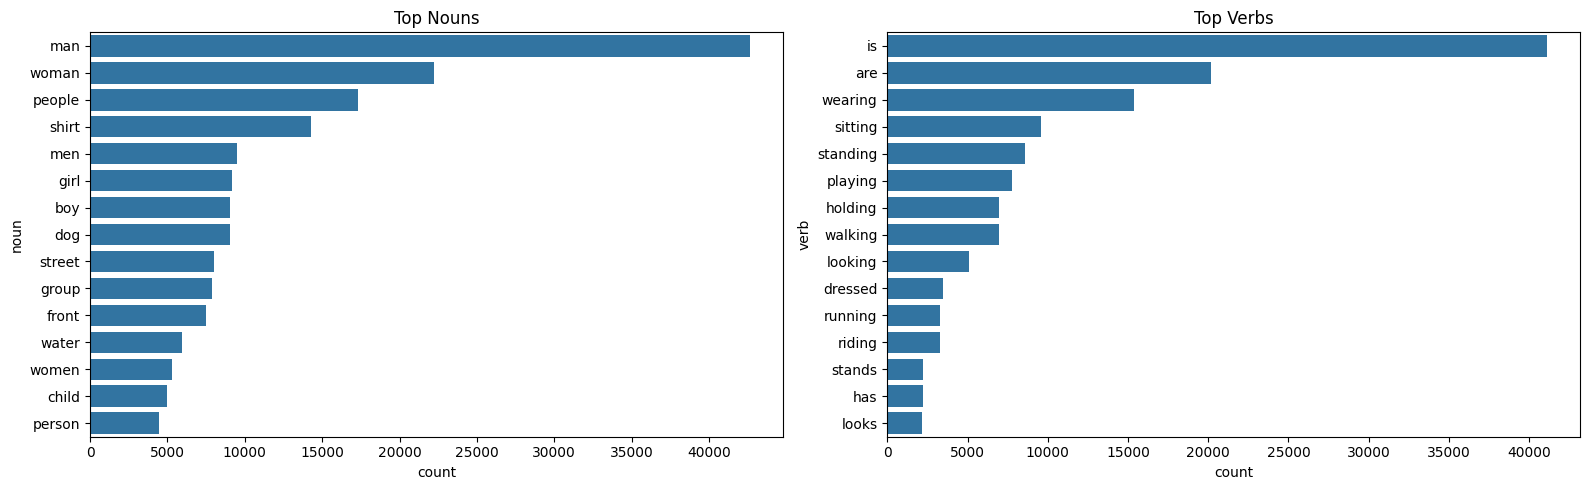

In [24]:
# Visual top tokens
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
if len(noun_top100) > 0:
    sns.barplot(data=noun_top100.head(15), x='count', y='noun', ax=axes[0])
    axes[0].set_title('Top Nouns')
if len(verb_top100) > 0:
    sns.barplot(data=verb_top100.head(15), x='count', y='verb', ax=axes[1])
    axes[1].set_title('Top Verbs')
plt.tight_layout()
plt.show()
        


#### 3.3 Multi-Caption Dynamics (1 image -> 5 captions)
- Intra-image diversity: pairwise Jaccard self-similarity among 5 captions of the same image
- Inter-image collisions: exact and near-identical caption reuse across different images
        


Intra-image Jaccard: 100%|Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†| 31783/31783 [00:03<00:00, 8037.24it/s] 


Intra-image self-similarity summary


count    31783.000000
mean         0.216784
std          0.080322
min          0.017809
50%          0.205850
95%          0.365583
99%          0.452690
max          0.745563
Name: mean_jaccard, dtype: float64

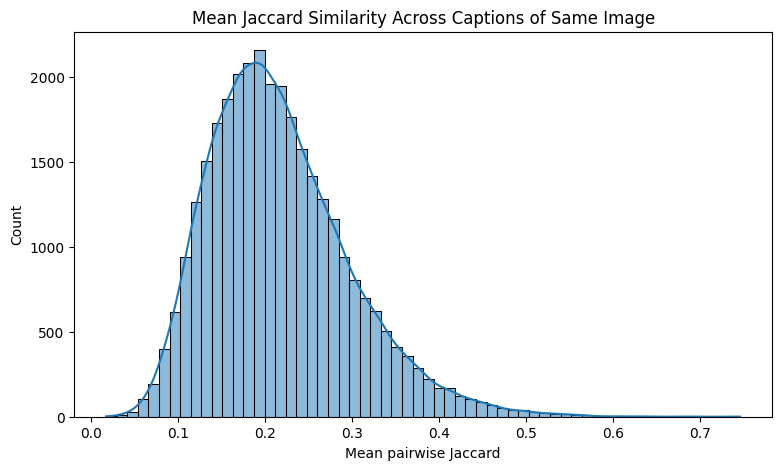

In [25]:
# ---- A) Intra-image diversity (self-similarity)
image_to_token_lists = text_df.groupby(IMAGE_COL)['tokens'].apply(list)

intra_records = []
for img_name, token_lists in tqdm(image_to_token_lists.items(), total=len(image_to_token_lists), desc='Intra-image Jaccard'):
    token_sets = [set(toks) for toks in token_lists if toks]
    if len(token_sets) < 2:
        continue

    pair_scores = []
    for a, b in combinations(range(len(token_sets)), 2):
        inter = len(token_sets[a] & token_sets[b])
        union = len(token_sets[a] | token_sets[b])
        pair_scores.append(inter / union if union else 0.0)

    intra_records.append({
        'image_name': img_name,
        'n_captions': len(token_sets),
        'mean_jaccard': float(np.mean(pair_scores)),
        'min_jaccard': float(np.min(pair_scores)),
        'max_jaccard': float(np.max(pair_scores)),
    })

intra_df = pd.DataFrame(intra_records)

print('Intra-image self-similarity summary')
if not intra_df.empty:
    display(intra_df['mean_jaccard'].describe(percentiles=[0.5, 0.95, 0.99]))
    plt.figure(figsize=(9, 5))
    sns.histplot(intra_df['mean_jaccard'], bins=60, kde=True)
    plt.title('Mean Jaccard Similarity Across Captions of Same Image')
    plt.xlabel('Mean pairwise Jaccard')
    plt.show()


In [26]:


# ---- B) Inter-image collisions
# Exact collision = same normalized caption mapped to multiple unique images
exact_collision = (
    text_df.groupby('comment_norm')[IMAGE_COL]
    .nunique()
    .reset_index(name='unique_images')
)
exact_collision = exact_collision[exact_collision['unique_images'] > 1]

print(f"Exact caption collisions (same text, different images): {len(exact_collision):,}")
if not exact_collision.empty:
    display(exact_collision.sort_values('unique_images', ascending=False).head(20))

# Near-collision heuristic: semantic fingerprint overlap across different images
STOPWORDS = {
    'a','an','the','is','are','was','were','in','on','at','to','of','and','with','for','by','from','this','that','it'
}

def semantic_fingerprint(tokens):
    content = [t for t in tokens if t not in STOPWORDS]
    if not content:
        content = tokens
    return ' '.join(sorted(set(content)))

text_df['semantic_fingerprint'] = text_df['tokens'].apply(semantic_fingerprint)

near_collision = (
    text_df.groupby('semantic_fingerprint')[IMAGE_COL]
    .nunique()
    .reset_index(name='unique_images')
)
near_collision = near_collision[
    (near_collision['semantic_fingerprint'].str.len() > 0)
    & (near_collision['unique_images'] > 1)
]

print(f"Near-collision fingerprints (heuristic) across images: {len(near_collision):,}")
if not near_collision.empty:
    display(near_collision.sort_values('unique_images', ascending=False).head(20))
        


Exact caption collisions (same text, different images): 382


,comment_norm,unique_images
17096,a dog runs through the grass .,7
140868,two dogs playing in the snow .,7
1475,a band is performing on stage .,6
65156,a person on a bmx bike .,6
140809,two dogs play together .,6
140790,two dogs play in the grass .,6
70707,a small image used to signify a broken web ima...,5
16843,a dog plays in the snow .,5
49630,a man is singing into a microphone .,5
17003,a dog runs across the grass .,5


Near-collision fingerprints (heuristic) across images: 902


,semantic_fingerprint,unique_images
49955,band performing stage,13
128832,dogs playing snow two,11
128509,dogs grass play two,9
146610,guitar man playing singing,8
128004,dog running snow through,8
150378,into man microphone singing,7
146622,guitar man playing stage,7
131234,down street walking woman,7
113185,climbing man rock,7
127173,dog grass runs through,7


#### 3.4 Dataset Pathology & Noise Auditing
- Semantic void detection
- Encoding/language purity checks
- Information-density profiling (char count vs unique descriptive words)
        


In [27]:
# ---- A) Semantic void detection (low-signal placeholders)
void_patterns = [
    r'^a picture of\b',
    r'^image showing\b',
    r'^no description\b',
    r'^n/?a$',
    r'^none$',
    r'^unknown$',
]
void_regex = re.compile('|'.join(void_patterns))

text_df['is_semantic_void'] = text_df['comment_norm'].apply(lambda x: bool(void_regex.search(x)))
void_rate = text_df['is_semantic_void'].mean()

print(f"Semantic void captions: {text_df['is_semantic_void'].sum():,} / {len(text_df):,} ({void_rate:.4%})")

Semantic void captions: 54 / 158,915 (0.0340%)


In [28]:
# ---- B) Encoding + language purity heuristics
text_df['has_replacement_char'] = text_df[TEXT_COL].str.contains('?', regex=False)
text_df['has_control_char'] = text_df[TEXT_COL].str.contains(r'[\x00-\x08\x0B\x0C\x0E-\x1F\x7F]', regex=True)
text_df['non_ascii_ratio'] = text_df[TEXT_COL].apply(lambda s: sum(ord(ch) > 127 for ch in s) / max(len(s), 1))

print('Encoding diagnostics')
print(f"- Rows with replacement char (?): {text_df['has_replacement_char'].sum():,}")
print(f"- Rows with control chars       : {text_df['has_control_char'].sum():,}")
print(f"- Mean non-ASCII ratio          : {text_df['non_ascii_ratio'].mean():.6f}")

Encoding diagnostics
- Rows with replacement char (?): 39
- Rows with control chars       : 0
- Mean non-ASCII ratio          : 0.000001


Correlation(char_count, unique_desc_words): 0.8537


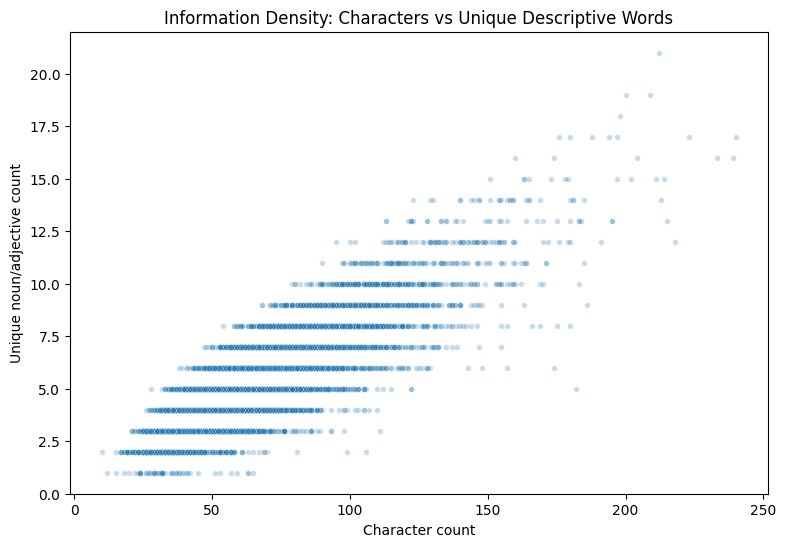

Low-information captions (<=1 unique noun/adjective): 0.35%
Very long captions (>=99th percentile char length): 1.03%


In [29]:
# ---- C) Information density profiling
if 'pos_tags' not in text_df.columns:
    print('POS tags not found. Run the POS profiling cell first for information-density metrics.')
else:
    text_df['char_count'] = text_df[TEXT_COL].str.len()
    text_df['unique_desc_words'] = text_df['pos_tags'].apply(
        lambda tags: len({w for w, t in tags if t.startswith('NN') or t.startswith('JJ')})
    )

    corr = text_df['char_count'].corr(text_df['unique_desc_words'])
    print(f"Correlation(char_count, unique_desc_words): {corr:.4f}")

    plot_sample = text_df.sample(min(12000, len(text_df)), random_state=42)
    plt.figure(figsize=(9, 6))
    sns.scatterplot(data=plot_sample, x='char_count', y='unique_desc_words', alpha=0.25, s=16)
    plt.title('Information Density: Characters vs Unique Descriptive Words')
    plt.xlabel('Character count')
    plt.ylabel('Unique noun/adjective count')
    plt.show()

    low_signal = (text_df['unique_desc_words'] <= 1).mean()
    very_long = (text_df['char_count'] >= text_df['char_count'].quantile(0.99)).mean()
    print(f"Low-information captions (<=1 unique noun/adjective): {low_signal:.2%}")
    print(f"Very long captions (>=99th percentile char length): {very_long:.2%}")
        




### Section 3 summary : Text Deep-Dive Profiling

Section 3 confirms that the caption corpus is clean, computationally manageable, and semantically informative, while also surfacing vocabulary skew and caption reuse patterns.

1. **3.1 Token & Compute Profiling**
   - Captions analyzed: **158,915** across **31,783** unique images.
   - DistilBERT WordPiece lengths are short and stable (mean **15.79**, median **15**, P95 **26**, P99 **34**, max **83**).
   - OOV risk is negligible: **0** [UNK] tokens out of **2,192,214** subword tokens.
   - **Insight:** Text encoder compute is predictable and tokenizer compatibility is excellent.

2. **3.2 Lexical & Semantic Topology**
   - POS mix: nouns **46.89%**, verbs **20.06%**, adjectives **12.26%**, prepositions **20.79%**.
   - Frequent terms are concentrated around common human/action concepts (man, woman, people, is, re, wearing, etc.).
   - Zipf-like rank-frequency behavior is visible, indicating a normal long-tail lexical distribution.
   - **Insight:** Captions are descriptive, but concept frequency is not uniform (possible retrieval bias toward dominant terms).

3. **3.3 Multi-Caption Dynamics (1 image -> 5 captions)**
   - Intra-image lexical overlap is moderate (mean Jaccard **0.2168**, median **0.2059**), showing useful variation across the 5 captions per image.
   - Cross-image reuse exists: **382** exact caption collisions and **902** near-collision semantic fingerprints.
   - **Insight:** Same-image captions are not overly redundant, but repeated caption templates across different images may introduce shortcut signals.

4. **3.4 Dataset Pathology & Noise Auditing**
   - Semantic-void captions are rare: **54 / 158,915 (0.0340%)**.
   - Encoding quality is high: **39** rows with replacement character markers, **0** control-character rows, near-zero non-ASCII ratio.
   - Information density is strong: correlation between caption length and unique descriptive words is **0.8537**.
   - **Insight:** Text noise is low and unlikely to be a major bottleneck for multimodal training.




####  Overall Summary 

`01_data_exploration.ipynb` establishes that Flickr30k is structurally clean and training-ready for CLIP-style multimodal retrieval.



- **Data integrity is excellent:** `158,915` captions map to `31,783` images with an exact `5 captions per image` pattern, no missing values, and no duplicate rows.
- **Image-side quality is stable:** all scanned files are readable and `100% RGB`; image dimensions show a dataset-level preprocessing cap at `500px` max edge.
- **Text-side quality is strong:** captions are short for transformer encoding (WordPiece mean length `15.79`), with effectively zero tokenizer OOV (`[UNK]` count `0`).
- **Caption diversity is moderate:** 5 captions per image provide useful lexical variation, but there is measurable cross-image caption reuse (exact and near-collisions).
- **Noise/pathology is low:** semantic-void captions and encoding anomalies are rare, and information density remains high.

#### Insights

1. **Keep defensive image preprocessing in place.**
Include `.convert("RGB")` and basic read checks in the dataset pipeline, even though current data is clean, to future-proof against upstream dataset changes.

2. **Use an efficient text length policy for training/inference.**
Given observed caption lengths, set a practical max text length (for example `32-64` tokens) and verify recall impact; this should reduce compute with minimal information loss.

3. **Mitigate lexical bias during evaluation and hard-negative mining.**
Track retrieval performance on concept slices (people, clothing, animals, actions) and use harder negatives to reduce over-reliance on dominant frequent terms.

4. **Guard against caption-template leakage across splits.**
Before final train/val/test exports, audit normalized caption collisions and near-collision fingerprints across splits to avoid inflated retrieval scores.

5. **Add lightweight text quality filters in preprocessing.**
Flag or clean semantic-void patterns and replacement-character rows; even at low frequency, this keeps training inputs consistently informative.

6. **Preserve multi-caption structure in training objectives.**
The moderate intra-image diversity supports multi-positive contrastive training (all 5 captions per image) rather than single-caption sampling.
